In [24]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")


In [25]:
# ─── Etapa 0: Preparación, descarga y graficas individuales ─────────────────── 

gold = yf.download('GC=F', start ='2020-01-01', end='2026-03-14')
crude = yf.download('CL=F', start = '2020-01-01', end = '2026-03-14')

g_df = pd.DataFrame(gold)
c_df = pd.DataFrame(crude)

c_df.columns = c_df.columns.droplevel(1)
g_df.columns = g_df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


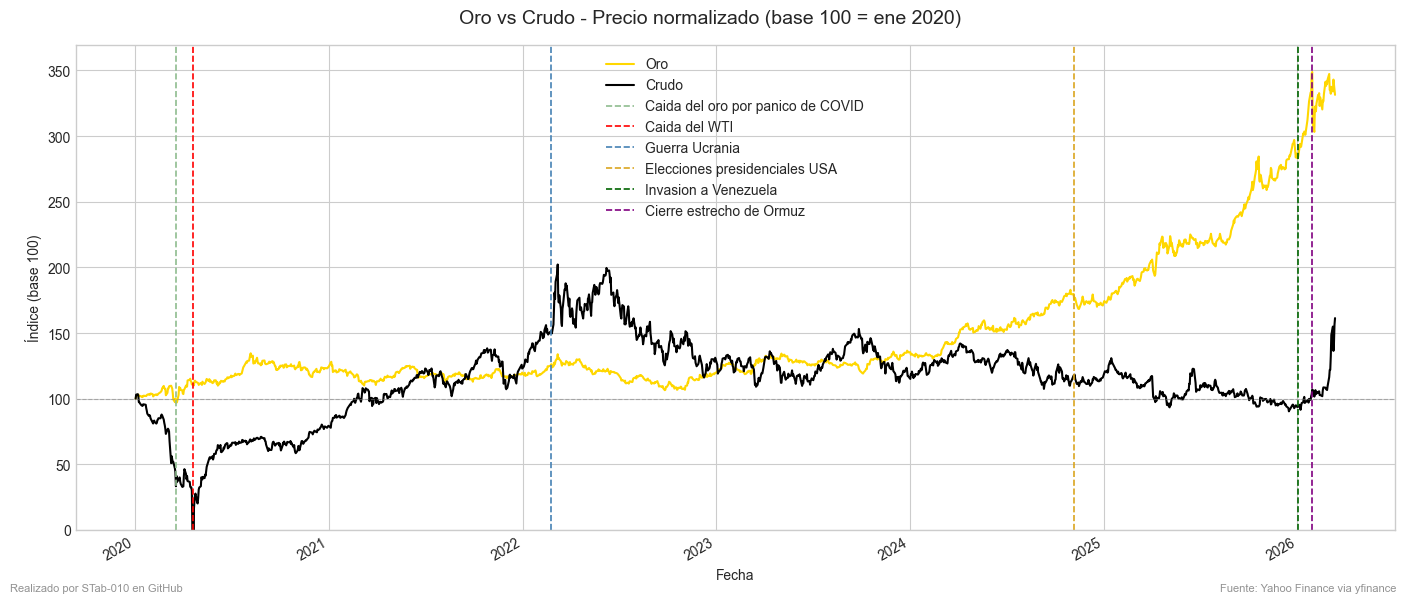

In [26]:
# ── Etapa 1: Normalización y graficas conjuntas ─────────────────

df_all = pd.DataFrame({
    'Gold': g_df['Close'],
    'Crude': c_df['Close']
})

df_all = df_all.dropna()

df_all_norm = df_all / df_all.iloc[0] * 100

fig, ax = plt.subplots(figsize = (14,6) )
fig.suptitle('Oro vs Crudo - Precio normalizado (base 100 = ene 2020)', fontsize=14)
df_all_norm['Gold'].plot(ax = ax, color = 'gold', linewidth = 1.5, label = 'Oro')
df_all_norm['Crude'].plot(ax = ax, color = 'black', linewidth = 1.5, label = 'Crudo')

ax.set_ylim(bottom = 0)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x = '2020-03-18', color = 'darkseagreen', linestyle = '--', linewidth = 1.2, label = 'Caida del oro por panico de COVID')
ax.axvline(x = '2020-04-20', color = 'red', linestyle = '--', linewidth = 1.2, label = 'Caida del WTI')
ax.axvline(x = '2022-02-24', color = 'steelblue', linestyle = '--', linewidth = 1.2, label = 'Guerra Ucrania')
ax.axvline(x = '2024-11-05', color = 'goldenrod', linestyle = '--', linewidth = 1.2, label = 'Elecciones presidenciales USA')
ax.axvline(x = '2026-01-03', color = 'darkgreen', linestyle = '--', linewidth = 1.2, label = 'Invasion a Venezuela')
ax.axvline(x = '2026-01-29', color = 'purple', linestyle = '--', linewidth = 1.2, label = 'Cierre estrecho de Ormuz')
ax.set_ylabel('Índice (base 100)')
ax.set_xlabel('Fecha')
ax.legend()
fig.text(0.99, 0.01, 'Fuente: Yahoo Finance via yfinance', 
         ha='right', fontsize=8, alpha=0.5)
fig.text(0, 0.01, 'Realizado por STab-010 en GitHub', 
         ha='left', fontsize=8, alpha=0.5)
plt.savefig('C:/DISEÑO/Analisis de datos/imagenes/precio_normalizado.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

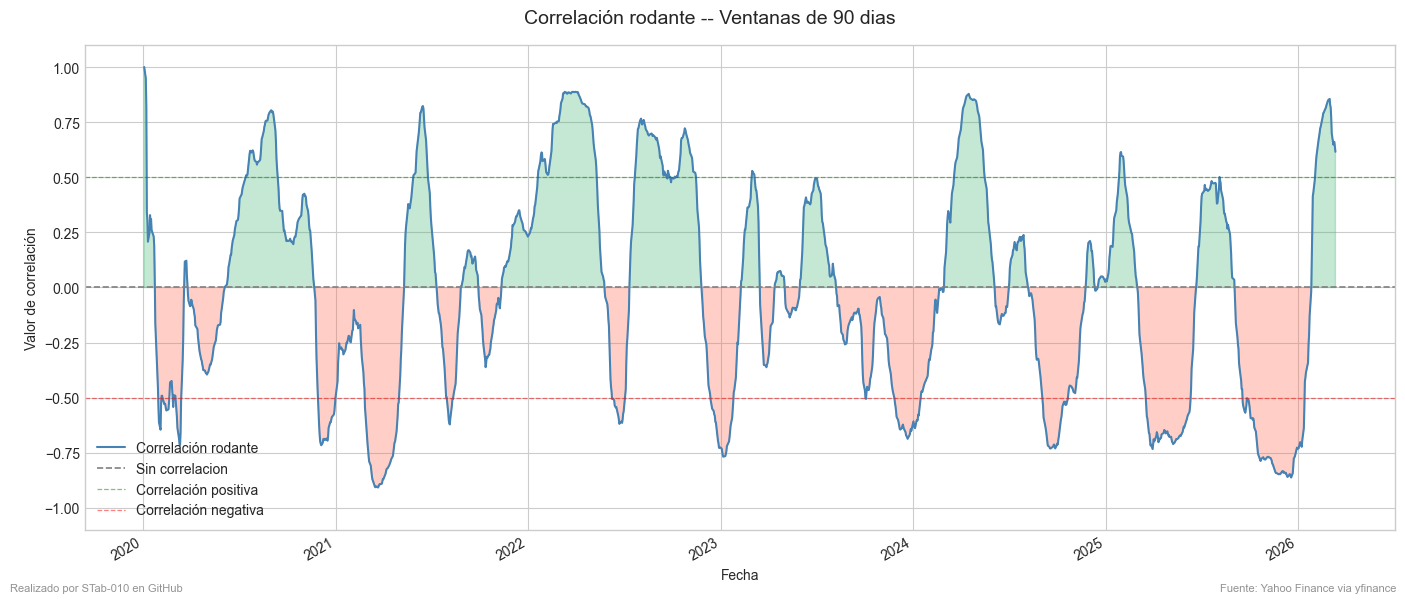

In [27]:
#──── Etapa 2: Correlaciones graficas ────────────────

corr_global = df_all['Gold'].corr(df_all['Crude'])
corr_rod = df_all['Gold'].rolling(window='90D').corr(df_all['Crude'])


fig, ax = plt.subplots(figsize = (14,6))
fig.suptitle('Correlación rodante -- Ventanas de 90 dias', fontsize = 14)
corr_rod.plot(ax = ax, color = 'steelblue', linewidth = 1.5, label = 'Correlación rodante')
ax.axhline(y = 0, color = 'grey', linestyle = '--', linewidth = 1.2, label = 'Sin correlacion ')
ax.axhline(y = 0.5, color = 'green', linestyle = '--', linewidth = 0.9, alpha = 0.5, label = 'Correlación positiva')
ax.axhline(y = -0.5, color = 'red', linestyle = '--', linewidth = 0.9, alpha = 0.5, label = 'Correlación negativa')
ax.set_ylabel('Valor de correlación')
ax.set_xlabel('Fecha')
ax.fill_between(corr_rod.index,corr_rod, 0, where = corr_rod.values > 0, color = 'mediumseagreen', alpha = 0.3)
ax.fill_between(corr_rod.index, corr_rod, 0, where = corr_rod.values < 0, color = 'tomato', alpha = 0.3)
ax.set_ylim(-1.1,1.1)
ax.legend()
fig.text(0.99, 0.01, 'Fuente: Yahoo Finance via yfinance', 
         ha='right', fontsize=8, alpha=0.5)
fig.text(0, 0.01, 'Realizado por STab-010 en GitHub', 
         ha='left', fontsize=8, alpha=0.5)
plt.savefig('C:/DISEÑO/Analisis de datos/imagenes/correlaciones.png', dpi=150, bbox_inches='tight')
plt.tight_layout()


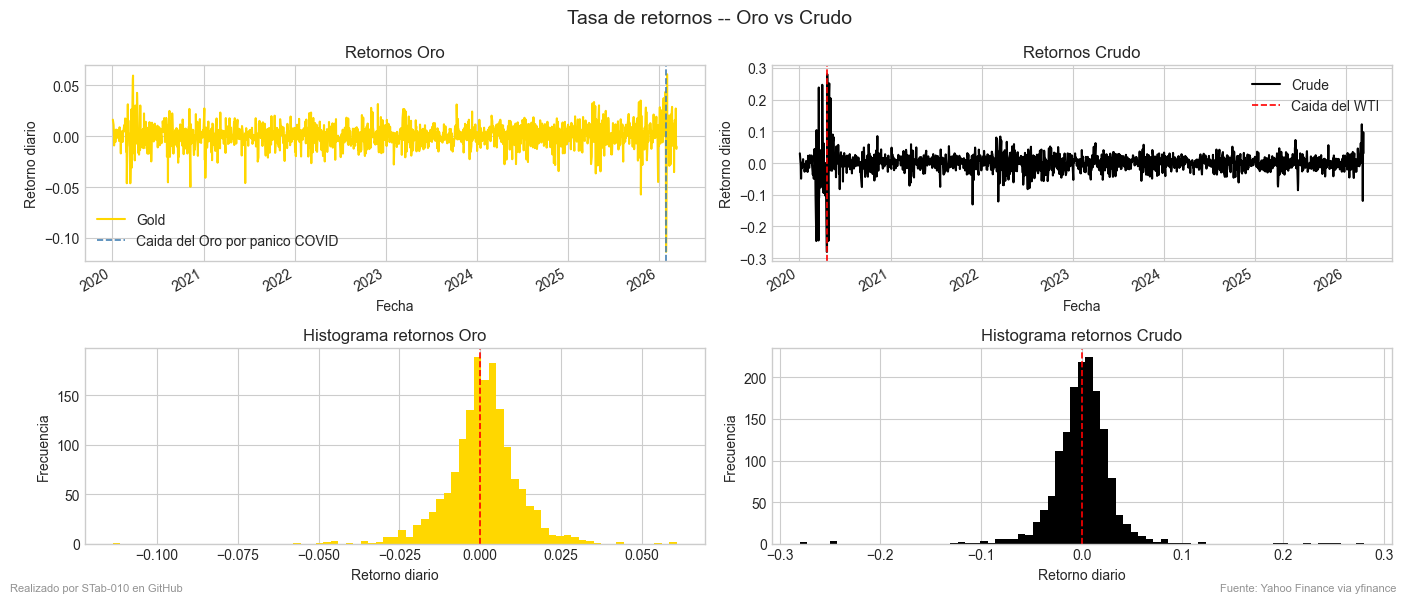

In [28]:
#─── Etapa 3: 

df_returns = df_all.pct_change().dropna()
df_returns_viz = df_returns.clip(lower = -0.28, upper = 0.28 )

fig, axs = plt.subplots(2,2, figsize = (14,6))
fig.suptitle('Tasa de retornos -- Oro vs Crudo', fontsize = 14)
axs[0,0].set_title('Retornos Oro')
axs[0,1].set_title('Retornos Crudo')
axs[1,0].set_title('Histograma retornos Oro')
axs[1,1].set_title('Histograma retornos Crudo')

df_returns_viz['Gold'].plot(ax = axs[0,0], color = 'gold')
df_returns_viz['Crude'].plot(ax = axs[0,1], color = 'black')
df_returns_viz['Gold'].hist(ax = axs[1,0], bins = 75, color = 'gold')
df_returns_viz['Crude'].hist(ax = axs[1,1], bins = 75, color = 'black')

axs[0,1].axvline(x = '2020-04-20', color = 'red', linestyle = '--', linewidth = 1.2, label = 'Caida del WTI')
axs[0,0].axvline(x = '2026-01-29', color = 'steelblue', linestyle = '--', linewidth = 1.2, label = 'Caida del Oro por panico COVID')
axs[1,0].axvline(x = 0, color = 'red', linestyle = '--', linewidth = 1.2)
axs[1,1].axvline(x = 0, color = 'red', linestyle = '--', linewidth = 1.2)

axs[0,0].set_xlabel('Fecha')
axs[0,0].set_ylabel('Retorno diario')
axs[0,1].set_xlabel('Fecha')
axs[0,1].set_ylabel('Retorno diario')
axs[1,0].set_xlabel('Retorno diario')
axs[1,0].set_ylabel('Frecuencia')
axs[1,1].set_xlabel('Retorno diario')
axs[1,1].set_ylabel('Frecuencia')
axs[0,1].legend()
axs[0,0].legend()

fig.text(0.99, 0.01, 'Fuente: Yahoo Finance via yfinance', 
         ha='right', fontsize=8, alpha=0.5)
fig.text(0, 0.01, 'Realizado por STab-010 en GitHub', 
         ha='left', fontsize=8, alpha=0.5)
plt.savefig('C:/DISEÑO/Analisis de datos/imagenes/retornos.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

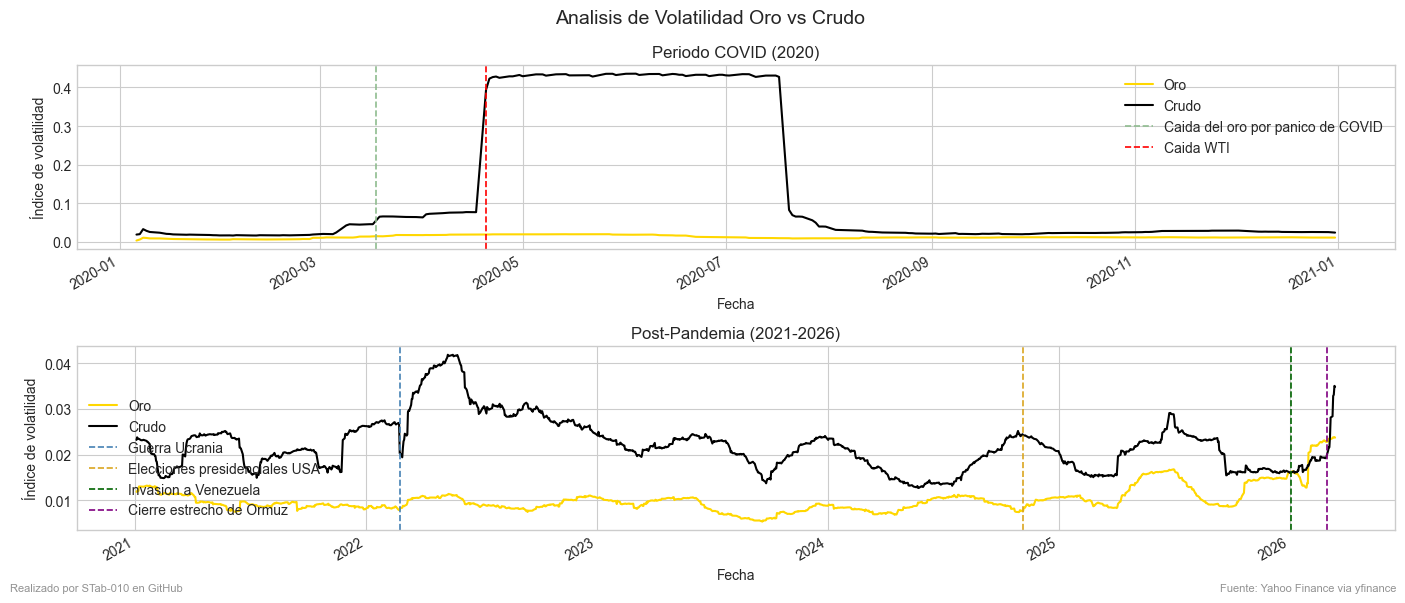

In [29]:
# ──── Etapa 4:

vol_rod = df_returns.rolling(window = '90D').std().dropna()

fig, axs = plt.subplots(2, 1, figsize = (14,6))
fig.suptitle('Analisis de Volatilidad Oro vs Crudo', fontsize = 14)
axs[0].set_title('Periodo COVID (2020)')
axs[1].set_title('Post-Pandemia (2021-2026)')
vol_rod[:'2021-01-01']['Gold'].plot(ax = axs[0], color = 'gold', label = 'Oro')
vol_rod[:'2021-01-01']['Crude'].plot(ax = axs[0], color = 'black', label = 'Crudo')
vol_rod['2021-01-01':]['Gold'].plot(ax = axs[1], color = 'gold', label = 'Oro')
vol_rod['2021-01-01':]['Crude'].plot(ax = axs[1], color = 'black', label = 'Crudo')
axs[0].set_xlabel('Fecha')
axs[0].set_ylabel('Índice de volatilidad')
axs[1].set_xlabel('Fecha')
axs[1].set_ylabel('Índice de volatilidad')
axs[0].axvline(x = '2020-03-18', color = 'darkseagreen', linestyle = '--', linewidth = 1.2, label = 'Caida del oro por panico de COVID')
axs[0].axvline(x = '2020-04-20', color = 'red', linestyle = '--', linewidth = 1.2, label = 'Caida WTI')
axs[1].axvline(x = '2022-02-24', color = 'steelblue', linestyle = '--', linewidth = 1.2, label = 'Guerra Ucrania')
axs[1].axvline(x = '2024-11-05', color = 'goldenrod', linestyle = '--', linewidth = 1.2, label = 'Elecciones presidenciales USA')
axs[1].axvline(x = '2026-01-03', color = 'darkgreen', linestyle = '--', linewidth = 1.2, label = 'Invasion a Venezuela')
axs[1].axvline(x = '2026-02-28', color = 'purple', linestyle = '--', linewidth = 1.2, label = 'Cierre estrecho de Ormuz')
axs[0].legend()
axs[1].legend(loc = 'lower left')
fig.text(0.99, 0.01, 'Fuente: Yahoo Finance via yfinance', 
         ha='right', fontsize=8, alpha=0.5)
fig.text(0, 0.01, 'Realizado por STab-010 en GitHub', 
         ha='left', fontsize=8, alpha=0.5)
plt.savefig('C:/DISEÑO/Analisis de datos/imagenes/volatilidades.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()



- La volatilidad del crudo es mayor y tiene mayor reaccion a eventos geopoliticos como el COVID, la guerra de Ucrania y el reciente cierre del estrecho de Ormuz

- En 2020-04-20 se vio un alza exponencial de la volatilidad del Crudo por el covid, momento en el que no habia capacidad para el almacenamiento, los futuros vencian y nadie deseaba recibir barriles fisicos.

- Aunque no reacciona igual, el crudo si reacciona volatilmente ante los eventos geopoliticos involucrados en su transporte, comercializacion o produccion.

In [30]:
#─── Etapa 5: 

drawdown_gold = (df_all_norm['Gold'] - df_all_norm['Gold'].cummax()) / df_all_norm['Gold'].cummax()
max_drawdown_gold = drawdown_gold.min()
drawdown_crude = (df_all_norm['Crude'] - df_all_norm['Crude'].cummax()) / df_all_norm['Crude'].cummax()
max_drawdown_crude = drawdown_crude.min()



metrics = pd.DataFrame({
    'Retorno total (%)': df_all_norm.iloc[-1] - 100,
    'Retorno diario promedio': df_returns.mean(),
    'Volatilidad promedio': df_returns.std(),
    'Máximo drawdown': pd.Series({
        'Gold': max_drawdown_gold,
        'Crude': max_drawdown_crude
    }),
    'Correlación global': pd.Series({
        'Gold': corr_global,
        'Crude': corr_global
    })
}).T.round(4)

metrics = metrics.rename(columns = {'Gold':'Oro', 'Crude':'Crudo'})
metrics


,Oro,Crudo
Retorno total (%),231.4201,61.3436
Retorno diario promedio,0.0008,-0.0016
Volatilidad promedio,0.0115,0.0899
Máximo drawdown,-0.2087,-1.5948
Correlación global,-0.0723,-0.0723


- Podemos ver que en 2020, en pandemia, el oro crece como respuesta al miedo por el COVID, y asi mismo vemos como el 20 de abril, el crudo cae historicamente a precios negativos por falta de almacenamiento.

- También es de notar que en el periodo analizado, el oro se comporta como un activo mucho menos volatil y seguro, con un crecimiento del 231%.

- El crudo es un activo altamente volatil, con retornos que aunque consistentes, son muy pequeños, vemos que el crudo responde fuertemente a los eventos geopoliticos notados en el periodo analizado.

- Observese que el oro actua a forma de refugio ante los eventos geopoliticos notados en este analisis,de manera que los inversionistas buscan asegurar su dinero en un activo altamente estable, en alza y con buenos retornos.

- Analizando la correlación, vemos que el valor -0.072 obtenido nos dice que son activos practicamente independientes, responden ambos a eventos geopoliticos pero no se relacionan mutuamente, que caiga el petroleo no necesariamente significará un alza o caida del oro.